# **Titanic Survival Analysis**
## **Classification(categorical output)**
Used when the target variable is categorical.

## Evaluation Metrics
1. Accuracy
2. Precision, recall, F1_Score
3. ROC-AUC curve

# **1. Logistic Regression**
- Titanic Dataset-Predicting survival

#### Dataset description
The titanic dataset contains information about passengers aboard the rms titanic including demographic details, ticket class and survival status. It is commonly used for binary classification problems where the goal is to predict whether a passenger `survived (1)` or  `not (0)` based on various features.
#### Objective
The goal of this project is to train a classification model(logistic regression) to predict whether a passenger survived the titanic disaster based on their attributes.

In [1]:
#Importing necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
#Reading the dataset
titanic=pd.read_csv("C:/Users/hp/Desktop/AMREC/titanic.csv")

In [3]:
#Viewing the first five rows
titanic.head()

,Unnamed: 0,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
#Structure of the dataset
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   891 non-null    int64  
 1   PassengerId  891 non-null    int64  
 2   Survived     891 non-null    int64  
 3   Pclass       891 non-null    object 
 4   Name         891 non-null    object 
 5   Sex          891 non-null    object 
 6   Age          714 non-null    float64
 7   SibSp        891 non-null    int64  
 8   Parch        891 non-null    int64  
 9   Ticket       891 non-null    object 
 10  Fare         891 non-null    float64
 11  Cabin        204 non-null    object 
 12  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(6)
memory usage: 90.6+ KB


In [5]:
#Checking for missing 
titanic.isnull().sum()

Unnamed: 0       0
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

There are missing values in the dataset:
- Age: 177 missing values
- Cabin: 687 missing values (most of the data is missing)
- Embarked: 2 missing

In [6]:
#Dropping the cabin variable(too missing values)
titanic.drop(columns=['Cabin'], inplace=True)
titanic.head()

,Unnamed: 0,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [7]:
#Filling the missing age variable with the median
titanic['Age'].fillna(titanic['Age'].median(), inplace=True)

In [8]:
#Fill the missing embarked with the mode (most frequent value)
titanic['Embarked'].fillna(titanic['Embarked'].mode()[0], inplace=True)

In [9]:
#Verify no missing value remains
print(titanic.isnull().sum())

Unnamed: 0     0
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


In [10]:
#The survival rate
titanic["Survived"].value_counts()

0    549
1    342
Name: Survived, dtype: int64

In [11]:
#Gender count
titanic["Sex"].value_counts()

male      577
female    314
Name: Sex, dtype: int64

<Axes: xlabel='count', ylabel='Sex'>

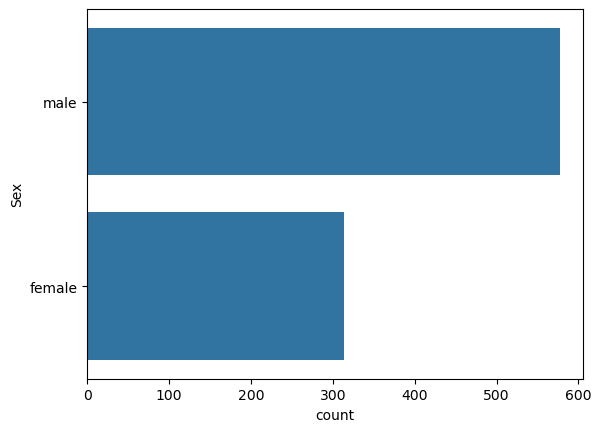

In [12]:
#Visualizing sex column
sns.countplot(titanic['Sex'])

<Axes: xlabel='Sex', ylabel='count'>

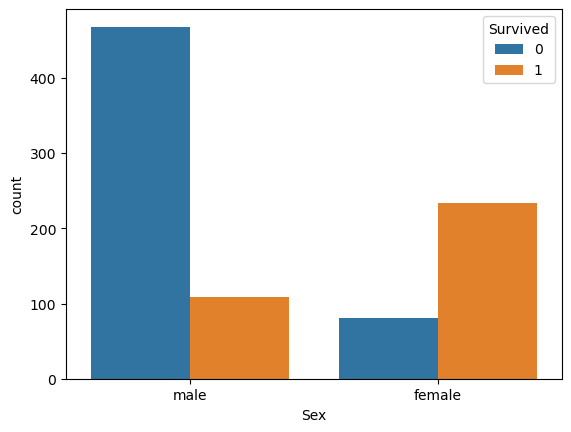

In [13]:
#Visualizing survival by sex
sns.countplot(x="Sex", hue="Survived", data=titanic)

In [14]:
#Checking for inconsistencies
print(titanic['Pclass'].unique())

['3' '1' '2' '?']


In [15]:
titanic['Pclass'].value_counts()

3    469
1    201
2    172
?     49
Name: Pclass, dtype: int64

In [16]:
#Replacing the ? with the null value (nan)
titanic["Pclass"]=titanic["Pclass"].replace("?", np.nan)

In [17]:
#Filling the missing with the mode then converting to integer
titanic['Pclass']=titanic['Pclass'].fillna(titanic['Pclass'].mode()[0]).astype(int)

In [18]:
#Verifying that pclass is now an integer and incosistency removed
print(titanic['Pclass'].dtypes)
print(titanic['Pclass'].unique())

int32
[3 1 2]


<Axes: xlabel='Pclass', ylabel='count'>

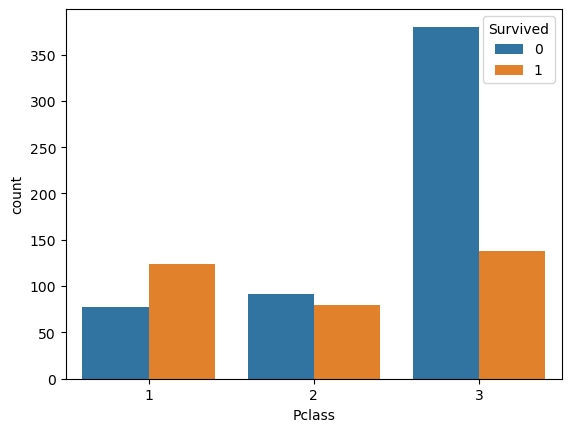

In [19]:
#Visualize Pclass with survival
sns.countplot(x='Pclass', hue='Survived', data=titanic)

### Encoding categorical variables
- Sex: Convert male to 0 and female to 1
- Embarked: Convert S to 0, C to 1 and Q to 2

In [20]:
#Encoding categorical variables
titanic.replace({"Sex":{"male":0, "female":1}, "Embarked":{"S":0, "C":1, "Q":2}}, inplace=True)

### Splitting the dataset
Now that our titanic dataset is clean we will split it into training and testing this allows us to train the model on one potion of data and evaluate it on the other.
### Define features and target variables
- Features `(x)`: These are independent variables used to predict the dependent variable
- Target `(y)`: The dependent which is survived (1=survived, 0=died) 

In [21]:
#Define features and target
x=titanic.drop(columns=['Unnamed: 0', 'PassengerId', 'Ticket', 'Survived', 'Name'])
y=titanic['Survived']

In [22]:
x.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,0,22.0,1,0,7.2500,0
1,1,1,38.0,1,0,71.2833,1
2,3,1,26.0,0,0,7.9250,0
3,1,1,35.0,1,0,53.1000,0
4,3,0,35.0,0,0,8.0500,0


In [23]:
y.head()

0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64

### 1. Split Training and Testing data

In [24]:
from sklearn.model_selection import train_test_split
#Splitting into 80% training and 20% testing 
x_train, x_test, y_train, y_test=train_test_split(x, y, test_size=0.2, random_state=42)
#Display dataset sizes
print(f"Training dataset:{x_train.shape}")
print(f"Test data: {x_test.shape}")

Training dataset:(712, 7)
Test data: (179, 7)


### 2. Initialize the model

In [25]:
from sklearn.linear_model import LogisticRegression
model_lr=LogisticRegression()

### 3. Training/Fitting logistic model
Now that we have pre-processed and standardised our dataset lets train a logistic regression model to predict survival.

In [26]:
#Training/fitting the model on training data
model_lr.fit(x_train, y_train)

LogisticRegression()

### 4. Making Predictions

In [27]:
#Making predictions on test set
y_pred_lr=model_lr.predict(x_test)

### Model Evaluation Metrics
We will evaluate the model using: 
- **Accuracy:** Overall correctness of predictions
- **Precision:** How many predict positives are actually correct
- **Recall:** How many actual positives were correctly identified
- **Confusion matrix:** Breakdown of true/false positives and negatives

### 5. Evaluating the model

In [28]:
#Importing necessary libraries
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
#calculating evaluation metrics
accuracy=accuracy_score(y_test, y_pred_lr)
precision=precision_score(y_test, y_pred_lr)
recall=recall_score(y_test, y_pred_lr)
conf_matrix=confusion_matrix(y_test, y_pred_lr)

In [29]:
#Displaying results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:{recall:.4f}")
print("Confusion Matrix:")
print(conf_matrix)

Accuracy: 0.7821
Precision: 0.7612
Recall:0.6892
Confusion Matrix:
[[89 16]
 [23 51]]


### Model Performance
The logistic regression performed as follows:
1. *Accuracy (0.7821)*: The model correctly predicted survival about 78.21% of the time
2. *Precision (0.7612)*: When model predicted survival it was correct 76.12% of the time
3. *Recall (0.6892)*: The model correctly identified 68.92% of the actual survivors
4. *Confusion matrix*:
- 89 true positive (correctly predicted didn't survive)
- 23 false negative (predicted survived but actally did not survive)
- 16 false positive (predicted did not survive but actually survived)
- 51 true negative (correctly predicted survived)

# **2. Random Forest (Classification)**

In [30]:
#importing necessary libraries
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

In [31]:
#Initialize the random forest model
model_rf=RandomForestClassifier(n_estimators=100, random_state=42)

In [32]:
#Fitting/Training the model
model_rf.fit(x_train, y_train)

RandomForestClassifier(random_state=42)

In [33]:
#Making predictions
y_pred_rf=model_rf.predict(x_test)

In [34]:
#Evaluating the model
accuracy_rf=accuracy_score(y_test, y_pred_rf)
precision_rf=precision_score(y_test, y_pred_rf)
recall_rf=recall_score(y_test, y_pred_rf)
conf_matrix=confusion_matrix(y_test, y_pred_rf)

In [35]:
#Displaying results
print(f"Accuracy: {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall:{recall_rf:.4f}")
print("Confusion Matrix:")
print(conf_matrix)

Accuracy: 0.8101
Precision: 0.7703
Recall:0.7703
Confusion Matrix:
[[88 17]
 [17 57]]


Random forest outperformed logistic regression on all metrics
- Accuracy: 81.01% vs 78.21%
- Precision: 77.03% vs 76.12%
- Recall: 77.03% vs 68.92%
- Confusion Matrix: True positive (88) and false negative (17) shows random forest correctly classifying more survivors. False positive (17) are slightly lower than before meaning fewer missing classified.

# **3. Decision Tree (Classification)**

In [36]:
#importing necessary libraries
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

In [37]:
#Initialize the model
model_dt=DecisionTreeClassifier(criterion="gini", random_state=42)

In [38]:
#Fitting the model
model_dt.fit(x_train, y_train)

DecisionTreeClassifier(random_state=42)

In [39]:
#Making predictions
y_pred_dt=model_dt.predict(x_test)

In [40]:
#Evaluating the model
accuracy_dt=accuracy_score(y_test, y_pred_dt)
precision_dt=precision_score(y_test, y_pred_dt)
recall_dt=recall_score(y_test, y_pred_dt)
conf_matrix=confusion_matrix(y_test, y_pred_dt)

In [41]:
#Displaying results
print(f"Accuracy: {accuracy_dt:.4f}")
print(f"Precision: {precision_dt:.4f}")
print(f"Recall:{recall_dt:.4f}")
print("Confusion Matrix:")
print(conf_matrix)

Accuracy: 0.7933
Precision: 0.7229
Recall:0.8108
Confusion Matrix:
[[82 23]
 [14 60]]


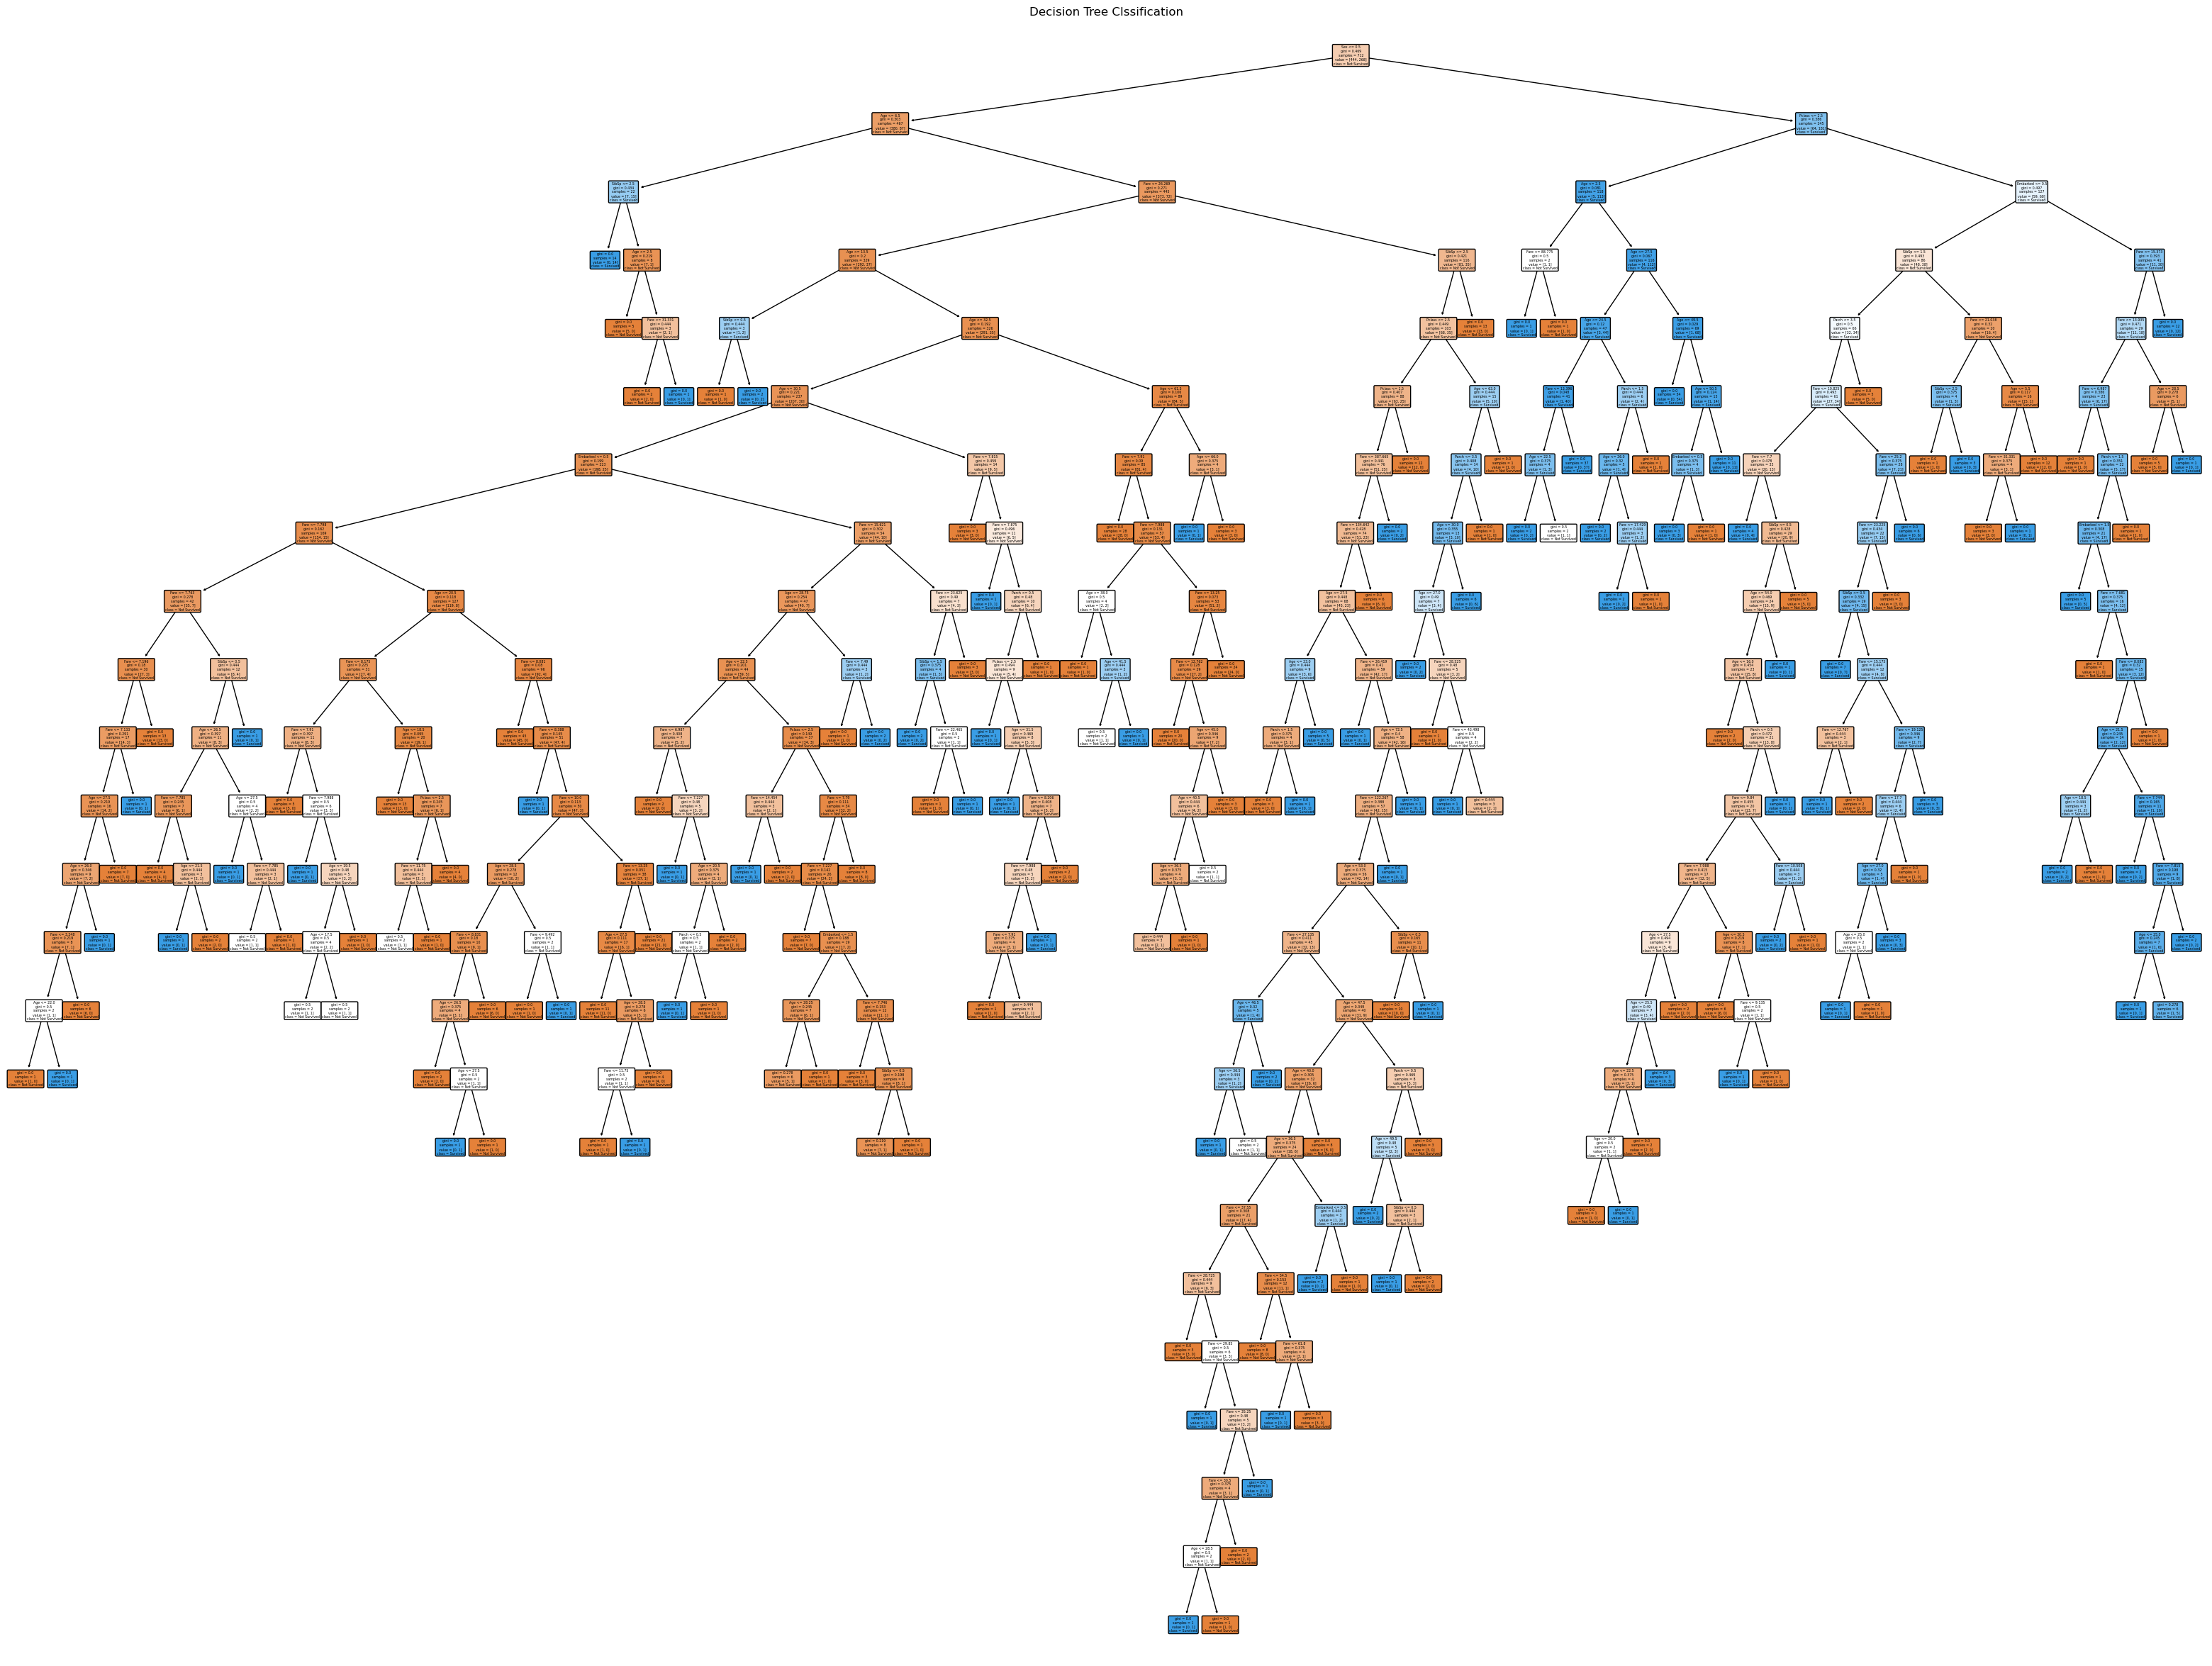

In [42]:
#visualizing decision tree
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
#plotting the tree
plt.figure(figsize=(40,30))
plot_tree(model_dt, filled=True, feature_names=list(x_train.columns), class_names=["Not Survived", "Survived"], rounded=True)
plt.title("Decision Tree Clssification")
plt.show()

#### Key Observations:
1. *Top of the tree (root node)*
   - The first split is the most important feature likely sex, fare or pclass in titanic dataset
   - This means the model starts by separating passengers based on that feature: for example, sex is usually the most informative.
2. *Branching parts*
   - Each left branch follows the rule feature, <= threshold
   - Each right branch follows feature > threshold
   - Nodes with lower gini are more pure (mostly 1+)
4. *Leaf nodes (bottom boxes)*
   - These are the final decisions
   - Nodes with value = [0,x] predict survived
   - Nodes with value = [x,0] predict not survived

# **4. K-Nearest Neighbours**

In [43]:
#import necessary librarires
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

In [44]:
#Initialize the scaler
scaler=StandardScaler()

In [45]:
#Fit on training data and transform both training and testing data 
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)


In [46]:
#Initialize the model
knn_model=KNeighborsClassifier(n_neighbors=5)
#Fit on standard training data
knn_model.fit(x_train_scaled, y_train)

KNeighborsClassifier()

In [47]:
#Make Predictions
y_pred=knn_model.predict(x_test_scaled)

In [48]:
#Evaluate the model
knn_accuracy=accuracy_score(y_test, y_pred)
knn_precision=precision_score(y_test, y_pred)
knn_recall=recall_score(y_test, y_pred)
knn_conf_matrix=confusion_matrix(y_test, y_pred)

In [49]:
#Displaying results
print(f"Accuracy: {knn_accuracy:.4f}")
print(f"Precision: {knn_precision:.4f}")
print(f"Recall:{knn_recall:.4f}")
print("Confusion Matrix:")
print(knn_conf_matrix)

Accuracy: 0.8045
Precision: 0.7826
Recall:0.7297
Confusion Matrix:
[[90 15]
 [20 54]]
